## Introduction

## 0.1 - Imports

In [39]:
# Import Library
import pandas as pd

# Sklearn Imports:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Data Display Imports
import matplotlib.pyplot as plt

## 0.2 Import Datasets

In [40]:
# Import the scaled dataset
customer_features_scaled = pd.read_csv('../0_Data/processed_data/customer_features_scaled.csv')

# Create a copy of the dataset we will be working on: 
scaled_df = customer_features_scaled.copy()

## 1.0 Preparation for Pipeline
At this point scaling and preprocessing has been completely finished. However there are still a few steps we need to confirm before creating the pipeline. The first is removing customer_id from the dataset but keeping to hand for later. The second is checking if columns in customer_fetures match the features from customer_features_scaled. This is done as feeding a csv file into our models would cause a mix up for which scaled values belongs to which feature. 

In [41]:
# pull customer_id into its own dataset; 
customer_ids = scaled_df['customer_id']

# Drop customer_id from the working dataset: 
scaled_df = scaled_df.drop(columns=['customer_id'])

def customer_features_removal(df):
    if scaled_df.columns.all() == 'customer_id':
        print("'customer_id' still present")
    else: print("'customer_id' successfully removed")

customer_features_removal(scaled_df)

'customer_id' successfully removed


## 2.0 - K-Means Algorithm

### 2.1 - k value determination
Before implementing k-means algorithms, we need to identify what value of 'k' is most suitable for our model. This will be done using elbow and silhoutte approaches. 

Explain why it is important to find the most suitable value of k? 

- elbow Method: 
the elbow method used 'inertia' as a way of measuring how closely points are plotted to each other. The logic is, as you add more points (increasing k) inertia decreased where eventually it hits 0. The key with this test is not identifying the lowest point but where the elbow is situated (displayed visually within a graph). The elbow represents the point at which increasing values of k stops providing value and start diluting clusters. 

- silhouette score: 
Silhouette score measures for seperation, which is different from inertia. for each point, the question is asked 'how close am i to my cluster'. More clusters are distinct from one another. n_int = 10 means KMeans is executed ten times with different seeds, retaining the best.  

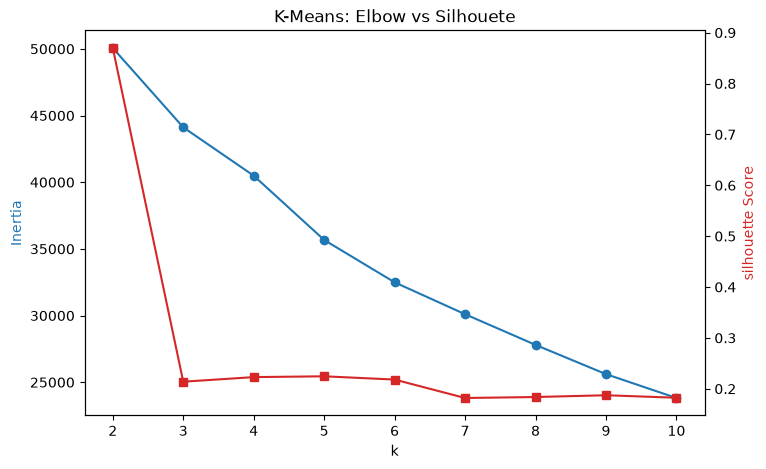

In [42]:
# initlise inertias and silhouette scroes lists:
inertias = []
silhouette_scores = []

# Initilise a range for k to be tested 2-10
k_range = range(2, 11)

# Initilise for each loop
for k in k_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(scaled_df)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(scaled_df, labels))

# Initilise visulisations: 
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

plt.title('K-Means: Elbow vs Silhouete')
plt.show()

Displays explaination in here: